# MOLIERE v1.0

**Title:** A Method Of Lines Integrator for Emissions Research and Exploration (MOLIERE) v 1.0  
**LLNL release:** LLNL-CODE-2017385  
**CP number:** CP 2025-187  
**Author:** Steven A. Hawks  
**License:** MIT (`SPDX-License-Identifier: MIT`)

In [5]:
# SPDX-License-Identifier: MIT
# Copyright (c) 2026, Lawrence Livermore National Security, LLC
# LLNL-CODE-2017385
# CP 2025-187
# Author: Steven A. Hawks

import numpy as np
from scipy.integrate import solve_ivp, simpson
import matplotlib.pyplot as plt
import time


def _extract_temp_profile(params):
    """Return a normalized temperature profile tuple."""
    if 'Tfinal' in params:
        T_target = params['Tfinal']
    elif 'Tmax' in params:
        T_target = params['Tmax']
    else:
        raise KeyError("temp_params must define 'Tfinal' (preferred) or 'Tmax'.")
    return params['dt1'], params['T0'], T_target, params['RR']


def mySystemWithSource(t, c, N, x, R, h, cD, beta, temp_params, flow_params, cfeed_params, src_params,
                       Vheadspace, F, Rgas, D0, EaD, K0, EaK, m):
    """
    Core system ODE function for the diffusion model.

    Parameters
    ----------
    t : float
        Current time point.
    c : ndarray
        Current concentration state.
    N : int
        Number of spatial nodes.
    x : ndarray
        Spatial coordinates.
    R : float
        Sample radius (cm).
    h : float
        Spatial step size (cm).
    cD : float
        Plasticizer power parameter (uM).
    beta : float
        Volume ratio (Vheadspace / vSample).
    temp_params, flow_params, cfeed_params, src_params : dict or ndarray
        Model parameters.
    """
    num_srcs = len(src_params) // 3

    if np.isinf(F):
        dcdt = np.empty(N + num_srcs, dtype=float)
    else:
        dcdt = np.empty(N + 1 + num_srcs, dtype=float)

    TC, dTdt = temperature(t, temp_params)
    T = TC + 273.15
    Q = flow_rate(t, flow_params)
    c_feed_ppbv = feed_conc(t, cfeed_params)
    c_feed_uM = c_feed_ppbv / 1000 / 22.414 * 273.15 / T

    K = K0 * np.exp(EaK / Rgas / T)
    dKdT_K = -EaK * dTdt / Rgas / T ** 2

    c_sample = c[:N]
    cR = c[N - 1]

    if np.isinf(cD):
        D = np.ones_like(c_sample) * D0 * np.exp(-EaD / (Rgas * T))
        dDdc = np.zeros_like(c_sample)
    else:
        D = D0 * np.exp(c_sample / cD - EaD / (Rgas * T))
        dDdc = D / cD

    # Interior point derivatives
    dcdx_interior = (c_sample[2:] - c_sample[:-2]) / (2 * h)
    d2cdx2_interior = (c_sample[2:] - 2 * c_sample[1:-1] + c_sample[:-2]) / h ** 2

    dcdt[1:N - 1] = (
        dDdc[1:-1] * dcdx_interior ** 2
        + D[1:-1] * (d2cdx2_interior + m * dcdx_interior / x[1:-1])
    )
    dcdt[0] = 2 * D[0] * (m + 1) * (c_sample[1] - c_sample[0]) / h ** 2

    if np.isinf(F):
        dcRdx = (3 * c_sample[-1] - 4 * c_sample[-2] + c_sample[-3]) / (2 * h)
        dcdt[N - 1] = (
            -(m + 1) * K * D[-1] * dcRdx / (R * beta)
            - cR * (Q / Vheadspace - dKdT_K)
            + Q * K * c_feed_uM / Vheadspace
        )
    else:
        c_gas = c[N]
        dcdx_at_R = 60 * F * (c_gas * K - cR) / D[-1]
        d2cdx2_at_R = 2 * (h * dcdx_at_R + c_sample[N - 2] - cR) / h ** 2
        dcdt[N - 1] = dDdc[-1] * dcdx_at_R ** 2 + D[-1] * (d2cdx2_at_R + m * dcdx_at_R / R)
        dcdt[N] = (m + 1) * 60 * F * (cR - c_gas * K) / (beta * R) + Q / Vheadspace * (c_feed_uM - c_gas)

    if num_srcs > 0:
        A = src_params[1::3]  # 1/min
        Ea = src_params[2::3]  # kJ/mol
        if np.isinf(F):
            dcdt[N:] = -A * np.exp(-Ea / Rgas / T) * c[N:]
            dcdt[:N - 1] += np.sum(-dcdt[N:])
        else:
            src_indices = slice(N + 1, N + 1 + num_srcs)
            rates = -A * np.exp(-Ea / (Rgas * T)) * c[src_indices]
            dcdt[src_indices] = rates
            dcdt[:N] -= np.sum(rates)
    return dcdt


def generate_jacobian_sparsity(N, src_params, F):
    """Generate a Jacobian sparsity pattern for the BDF solver."""
    num_srcs = len(src_params) // 3
    if np.isinf(F):
        total_vars = N + num_srcs
        sparsity = np.zeros((total_vars, total_vars), dtype=bool)
        for i in range(N):
            sparsity[i, i] = True
        for i in range(1, N - 1):
            sparsity[i, i - 1] = True
            sparsity[i, i + 1] = True
        if N > 1:
            sparsity[0, 1] = True
        if N - 1 >= 1:
            sparsity[N - 1, N - 2] = True
        if N - 1 >= 2:
            sparsity[N - 1, N - 3] = True
        for src_i in range(num_srcs):
            row_src = N + src_i
            sparsity[row_src, row_src] = True
        for i in range(N - 1):
            for src_i in range(num_srcs):
                sparsity[i, N + src_i] = True
    else:
        total_vars = N + 1 + num_srcs
        sparsity = np.zeros((total_vars, total_vars), dtype=bool)
        for i in range(N):
            sparsity[i, i] = True
        for i in range(1, N - 1):
            sparsity[i, i - 1] = True
            sparsity[i, i + 1] = True
        if N > 1:
            sparsity[0, 1] = True
        if N - 1 >= 1:
            sparsity[N - 1, N - 2] = True
        sparsity[N - 1, N] = True
        sparsity[N, N - 1] = True
        sparsity[N, N] = True
        for src_i in range(num_srcs):
            row_src = (N + 1) + src_i
            sparsity[row_src, row_src] = True
        for i in range(N):
            for src_i in range(num_srcs):
                sparsity[i, (N + 1) + src_i] = True
    return sparsity.astype(int)


In [6]:
# %% [Cell 3] Model Functions

def normalize_temp_params(params):
    """Return a copy of temp_params with both Tfinal and Tmax populated."""
    dt1, T0, T_target, RR = _extract_temp_profile(params)
    return {
        'dt1': dt1,
        'T0': T0,
        'Tfinal': T_target,
        'Tmax': T_target,
        'RR': RR,
    }


def validate_inputs(tfinal, temp_params, flow_params, cfeed_params,
                    m, R, mSample, rhoSample, Vvessel,
                    src_params, cD, F, cgas_init, N):
    """Validate user inputs and return a normalized src_params array."""
    src_params = np.asarray(src_params, dtype=float)

    if int(N) != N or N < 3:
        raise ValueError('N must be an integer >= 3.')
    if tfinal <= 0:
        raise ValueError('tfinal must be positive.')
    if R <= 0:
        raise ValueError('R must be positive.')
    if mSample <= 0 or rhoSample <= 0:
        raise ValueError('mSample and rhoSample must be positive.')
    if Vvessel <= mSample * 1e-3 / rhoSample:
        raise ValueError('Vvessel must be larger than the sample volume.')
    if src_params.size % 3 != 0:
        raise ValueError('src_params must contain groups of three values: c0, A, Ea.')
    if not np.isinf(cD) and cD <= 0:
        raise ValueError('cD must be positive or np.inf.')
    if not np.isinf(F) and F < 0:
        raise ValueError('F must be non-negative or np.inf.')
    if cgas_init < 0:
        raise ValueError('cgas_init must be non-negative.')
    if m not in (0, 1, 2):
        raise ValueError('m must be 0 (slab), 1 (cylinder), or 2 (sphere).')

    dt1, T0, T_target, RR = _extract_temp_profile(temp_params)
    if RR == 0 and not np.isclose(T_target, T0):
        raise ValueError('RR must be nonzero when T0 and Tfinal differ.')
    if flow_params['tEq'] + flow_params['tFlush'] <= 0:
        raise ValueError('tEq + tFlush must be positive.')

    n_steps = cfeed_params['n_steps']
    if int(n_steps) != n_steps or n_steps < 0:
        raise ValueError('n_steps must be a non-negative integer.')
    if n_steps > 0 and cfeed_params['step_time'] <= 0:
        raise ValueError('step_time must be positive when n_steps > 0.')
    total_feed_time = (
        cfeed_params['hold_time_initial']
        + 2 * int(n_steps) * cfeed_params['step_time']
        + cfeed_params['hold_time_final']
    )
    if total_feed_time <= 0:
        raise ValueError('The total feed profile duration must be positive.')

    return src_params


def temperature(t, params):
    """
    Calculate temperature at time t based on temperature profile parameters.

    Returns
    -------
    tuple[float, float]
        Temperature in deg C and dT/dt in deg C/min.
    """
    dt1, T0, Tfinal, RR = _extract_temp_profile(params)

    delta_T = Tfinal - T0
    if np.isclose(delta_T, 0.0):
        return T0, 0.0
    if RR == 0:
        raise ValueError('RR must be nonzero when T0 and Tfinal differ.')

    RR_corrected = np.sign(delta_T) * abs(RR)
    ramp_duration = abs(delta_T) / abs(RR)

    if t <= dt1:
        return T0, 0.0
    if t <= dt1 + ramp_duration:
        return T0 + RR_corrected * (t - dt1), RR_corrected
    return Tfinal, 0.0


def flow_rate(t, params):
    """Calculate flow rate at time t based on flow profile parameters."""
    tEq, tFlush, Q = params['tEq'], params['tFlush'], params['Q']
    period = tEq + tFlush
    if period <= 0:
        raise ValueError('tEq + tFlush must be positive.')
    t_mod = t % period
    return 0.0 if t_mod < tEq else Q


def feed_conc(t, cfeed_params):
    """Calculate feed concentration at time t."""
    n_steps = int(cfeed_params['n_steps'])
    delta = cfeed_params['delta']
    step_time = cfeed_params['step_time']
    base_conc = cfeed_params['base_conc']
    hold_time_initial = cfeed_params['hold_time_initial']
    hold_time_final = cfeed_params['hold_time_final']

    if n_steps == 0:
        return base_conc
    if step_time <= 0:
        raise ValueError('step_time must be positive when n_steps > 0.')

    total_time = hold_time_initial + 2 * n_steps * step_time + hold_time_final
    if total_time <= 0:
        raise ValueError('The total feed profile duration must be positive.')
    t_cycle = t % total_time

    if t_cycle < hold_time_initial or t_cycle >= total_time - hold_time_final:
        return base_conc

    t_active = t_cycle - hold_time_initial
    current_step = int(t_active / step_time)

    if current_step < n_steps:
        return base_conc + (current_step + 1) * delta
    steps_remaining = 2 * n_steps - current_step - 1
    return base_conc + steps_remaining * delta


In [7]:
# %% [Cell 4] Main Simulation Function

def run_simulation(tfinal, temp_params, flow_params, cfeed_params,
                   m, R, mSample, rhoSample, Vvessel, MW_analyte,
                   src_params, EaK, K50, D50, EaD, cD, F, c0free, cgas_init, N):
    """Run the diffusion simulation with the given parameters."""
    src_params = validate_inputs(
        tfinal, temp_params, flow_params, cfeed_params,
        m, R, mSample, rhoSample, Vvessel,
        src_params, cD, F, cgas_init, N,
    )
    temp_params = normalize_temp_params(temp_params)

    num_srcs = len(src_params) // 3
    vSample = mSample * 1e-3 / rhoSample  # ml
    Vheadspace = Vvessel - vSample        # ml
    beta = Vheadspace / vSample
    Rgas = 8.31446261815324 / 1000        # kJ/mol/K
    K0 = K50 * np.exp(-EaK / Rgas / (50 + 273.15))
    D0 = 60 * D50 * np.exp(EaD / Rgas / (50 + 273.15))  # cm^2/min

    x = np.linspace(0, R, N)
    h = x[1] - x[0]

    K_t0 = K0 * np.exp(EaK / Rgas / (temp_params['T0'] + 273.15))

    # Initial conditions
    c_initial = np.full(N, c0free, dtype=float)
    if np.isinf(F):
        c_initial[-1] = cgas_init * K_t0
        if num_srcs > 0:
            initial_conditions = np.hstack((c_initial, src_params[::3]))
        else:
            initial_conditions = c_initial
    else:
        if num_srcs > 0:
            initial_conditions = np.hstack((c_initial, [cgas_init], src_params[::3]))
        else:
            initial_conditions = np.hstack((c_initial, [cgas_init]))

    jac_sparsity = generate_jacobian_sparsity(N, src_params, F)

    # Integration using solve_ivp
    start_time = time.time()
    result = solve_ivp(
        lambda t, c: mySystemWithSource(
            t, c, N, x, R, h, cD, beta, temp_params, flow_params, cfeed_params,
            src_params, Vheadspace, F, Rgas, D0, EaD, K0, EaK, m,
        ),
        [0, tfinal],
        initial_conditions,
        method='BDF',
        rtol=1e-7,
        atol=1e-8,
        jac_sparsity=jac_sparsity,
        max_step=tfinal / 10,
    )
    runtime = time.time() - start_time
    print(f'Solve time: {runtime:.4f} seconds')

    if not result.success:
        raise RuntimeError(f'solve_ivp failed: {result.message}')

    t = result.t
    y = result.y.T
    cR = y[:, N - 1]

    # Post-processing
    T = np.array([temperature(ti, temp_params)[0] for ti in t])
    Q = np.array([flow_rate(ti, flow_params) for ti in t])
    K = K0 * np.exp(EaK / Rgas / (T + 273.15))
    S = K * (273.15 / (T + 273.15))
    if np.isinf(cD):
        DR = D0 * np.exp(-EaD / Rgas / (T + 273.15))
    else:
        DR = D0 * np.exp(-EaD / Rgas / (T + 273.15)) * np.exp(cR / cD)
    c_feed_ppbv = np.array([feed_conc(ti, cfeed_params) for ti in t])
    c_feed_uM = c_feed_ppbv / 1000 / 22.414 * 273.15 / (T + 273.15)
    c_feed_ugm3 = c_feed_uM * 1000 * MW_analyte

    if np.isinf(F):
        c_gas = cR / K
        src_off = N
    else:
        c_gas = y[:, N]
        src_off = N + 1

    cGas_ugm3 = c_gas * 1000 * MW_analyte
    cGasPPBV = c_gas * 1000 * 22.414 / 273.15 * (T + 273.15)
    cGasPPBVEq = c0free / (K + beta) * 1000 * 22.414 / 273.15 * (T + 273.15)

    # Mass balance calculations
    initial_integral = simpson(y[0, :N] * x ** m, x=x)
    time_integrals = np.array([simpson(y[i, :N] * x ** m, x=x) for i in range(len(t))])
    delta_mass_sample_free = -(m + 1) / R ** (m + 1) * vSample * MW_analyte * (initial_integral - time_integrals)

    if num_srcs > 0:
        delta_mass_sample_source = -vSample * MW_analyte * np.sum(
            [src_params[3 * j] - y[:, src_off + j] for j in range(num_srcs)],
            axis=0,
        )
    else:
        delta_mass_sample_source = np.zeros_like(t)

    delta_mass_sample_total = delta_mass_sample_free + delta_mass_sample_source

    c0_end = (m + 1) / R ** (m + 1) * simpson(y[-1, :N] * x ** m, x=x)
    c_gas_end = c_gas[-1] * beta
    initial_total = c0free + beta * cgas_init + float(np.sum(src_params[::3]))
    final_source_total = float(np.sum(y[-1, src_off:src_off + num_srcs])) if num_srcs > 0 else 0.0
    final_total = c0_end + c_gas_end + final_source_total
    net_outflow = simpson(Q * (c_gas - c_feed_uM) / vSample, x=t)
    denom = initial_total - final_total

    if np.abs(denom) < 1e-3:
        print('Warning: denominator nearly zero. Using absolute error metric instead.')
        print(f'Mass Balance Error = {100 * net_outflow:.2g} %')
    else:
        mass_balance_ratio = net_outflow / denom
        print(f'Mass Balance Error = {100 * (1 - mass_balance_ratio):.2g} %')

    return {
        't (min)': t,
        'c_gas (uM)': c_gas,
        'c_gas (ug/m^3)': cGas_ugm3,
        'c_gas (ppbv)': cGasPPBV,
        'T (C)': T,
        'Δm (ng)': delta_mass_sample_total,
        'cGasEq (ppbv)': cGasPPBVEq,
        'Q (ml/min)': Q,
        'c_feed (uM)': c_feed_uM,
        'c_feed (ppbv)': c_feed_ppbv,
        'c_feed (ug/m^3)': c_feed_ugm3,
        'K': K,
        'S (cm^3 @ STP/atm/cm^3 sample)': S,
        'D @ R (cm^2/min)': DR,
    }


Solve time: 0.2077 seconds
Mass Balance Error = 0.00011 %


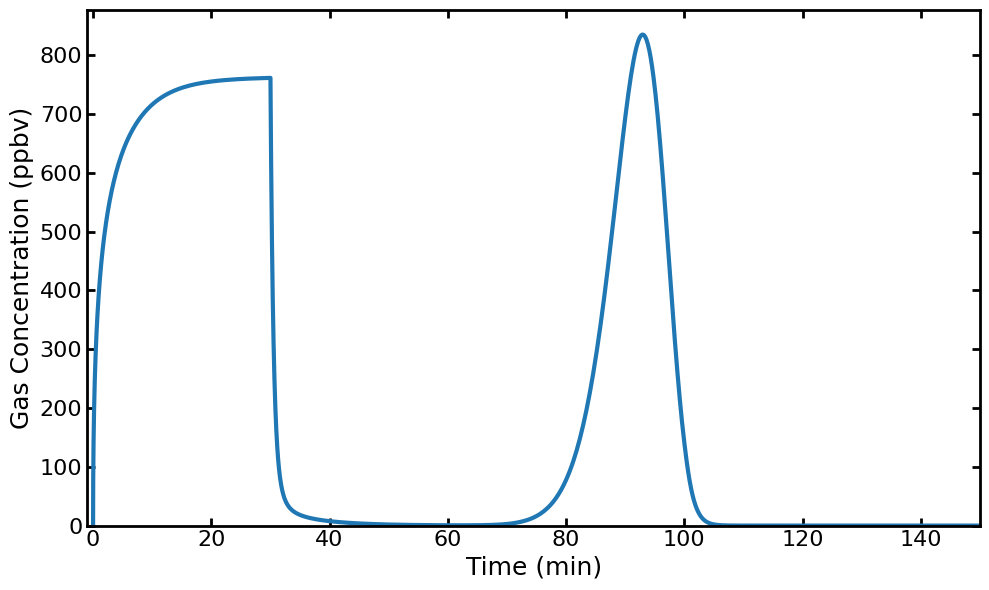

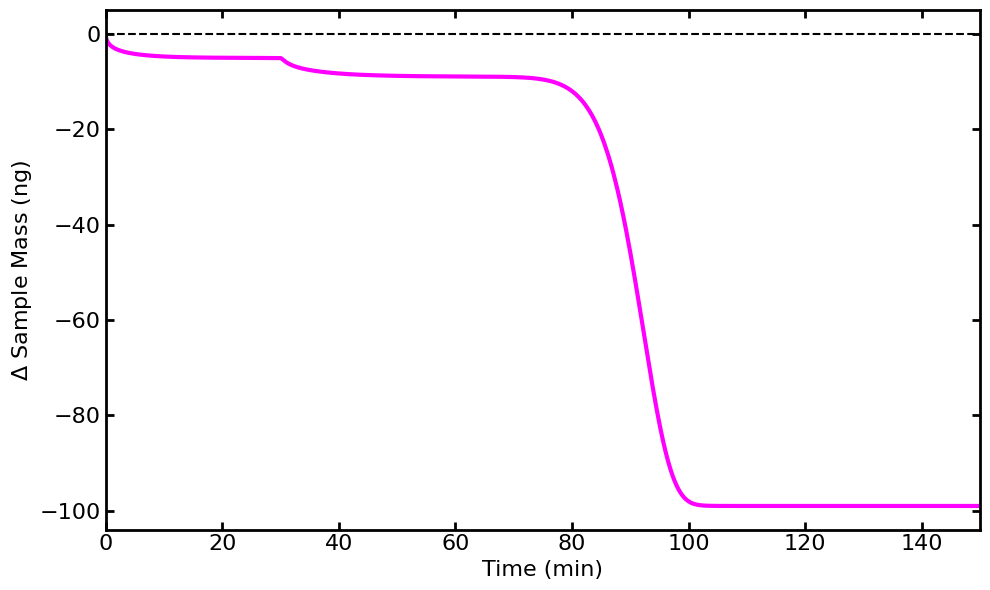

In [8]:
# %% [Cell 5] Input Parameters
# SIMULATION PARAMETERS
tfinal = 150  # Final simulation time (min)
N = 201 # number of grid points

# Temperature Profile parameters
temp_params = {
    'dt1': 60,    # min (initial isothermal period)
    'T0': 50,       # °C, initial temperature
    'Tfinal': 250,    # °C, maximum temperature
    'RR': 5      # °C/min, ramp rate
}

# Flow parameters
flow_params = {
    'tEq': 30,         # min, time at which Q = 0
    'tFlush': tfinal, # min, flushing time (when Q becomes active)
    'Q': 20           # ml/min, flow rate
}

# Feed concentration profile parameters
cfeed_params = {
    'n_steps': 0,               # number of steps
    'delta': 1000,              # ppbv, concentration change per step
    'step_time': 240,           # min, time for each step
    'base_conc': 0,             # ppbv, base concentration
    'hold_time_initial': 60,    # min, initial hold time
    'hold_time_final': 3000     # min, final hold time
}

# Sample and vessel characteristics
m = 2               # 0 = slab, 1 = cylinder, 2 = sphere
R = 200e-4          # cm, sample radius
mSample = 50        # mg, mass of sample
rhoSample = 1       # g/ml, density of sample
Vvessel = 10        # ml, vessel volume
MW_analyte = 18.0   # g/mol, molecular weight of analyte

# Source parameters: empty array for no chemical sources
# src_params = np.array([]) # Empty = no sources
# Example with sources:
src_params = np.array([100, 1E8, 80])  # list of: c0 (uM), A (1/min), Ea (kJ/mol), c0 (uM),...etc.

# Other parameters
EaK = 35      # kJ/mol
K50 = 150     # K at 50 °C
D50 = 1E-7    # cm^2/s at 50 °C
EaD = 15      # kJ/mol
cD = np.inf      # uM, plasticizer power parameter
F = np.inf      # cm/s; use np.inf for infinite flow condition
c0free = 10  # uM, initial free concentration
cgas_init = 0 # uM, initial gas concentration

# %% [Cell 6] Run Simulation and Plot Results
# Run the simulation
results = run_simulation(tfinal, temp_params, flow_params, cfeed_params,
                         m, R, mSample, rhoSample, Vvessel, MW_analyte,
                         src_params, EaK, K50, D50, EaD, cD, F, c0free, cgas_init, N)

# Plot gas concentration
plt.figure(figsize=(10, 6))
plt.plot(results['t (min)'], results['c_gas (ppbv)'], label='c_gas', linewidth=3)
plt.xlim([np.min(results['t (min)']), np.max(results['t (min)'])])
plt.xlabel('Time (min)', fontsize=18)
plt.ylabel('Gas Concentration (ppbv)', fontsize=18)
plt.tick_params(axis='both', which='major', top=True, right=True, labelsize=16,
                direction='in', length=6, width=2)
plt.tick_params(axis='y', which='minor', right=True, direction='in', length=4, width=1.5)
plt.xlim(left=-1)
plt.ylim(bottom=0)
ax = plt.gca()
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
plt.tight_layout()
plt.show()

# Plot sample mass change
plt.figure(figsize=(10, 6))
plt.plot(results['t (min)'], results['Δm (ng)'], 
         label='Sample mass change', linewidth=3, color='magenta')
plt.xlabel('Time (min)', fontsize=16)
plt.ylabel('$\\Delta$ Sample Mass (ng)', fontsize=16)
plt.xlim([np.min(results['t (min)']), np.max(results['t (min)'])])
plt.axhline(y=0, color='black', linestyle='--')
plt.tick_params(axis='both', which='major', top=True, right=True, labelsize=16,
                direction='in', length=6, width=2)
ax = plt.gca()
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
plt.tight_layout()
plt.show()
# Optional export: import pandas as pd; pd.DataFrame(results).to_clipboard(index=False)
